# GEOG 412: Programming for Geospatial Data Science, Unit 5

## Assignment 5: Geospatial Application Development

For this assignment, you will...

*   Complete a series of five "warm-up" exercises designed to help you practice the visualization and raster analysis techniques presented in this unit in a targeted manner (five points altogether);
*   Complete an open-ended Python programming exercise (fifteen points).



Your code should be written directly within a copy of this notebook, and you should upload a copy of your notebook to the course website as you have done for previous assignments.

**To begin, choose "Save a copy in Drive" from the File menu to create your own copy of this notebook.**

Let's begin by installing some dependencies (run every time your Python runtime clears)...

In [ ]:
!pip install geopandas rasterio keplergl

## Warm-Up Exercises

Each one of these exercises will involve practicing specific elements of the raster analysis and geovisualization techniques that are covered in this unit.  These exercises are designed to ensure that you are familiar with common methods associated with the structure of Web-based maps as well as various features of GeoPandas.

**Please note that these exercises require the use of various assignment and demonstration data files.**  These data files are all available on the course website and must be uploaded to your Colab environment.

The following exercises are worth one point each.

###Exercise 1

Using Rasterio and both (1) the temperature raster and the (2) TIGER/Line places dataset posted on the course website, display the five warmest and five coolest populated places within a state of your choice.

In [ ]:
# Code for exercise 1 goes here

import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.plot import show
from matplotlib import pyplot as plt

temperature = rasterio.open('temperature.tif')

places = gpd.read_file('tl21_places.gpkg')
places = places.to_crs(epsg=3857)
places['geometry'] = places['geometry'].centroid
places_list = [(x, y) for x, y in zip(places['geometry'].x, places['geometry'].y)]
places['avg_temp'] = [x[0] for x in temperature.sample(places_list)]
places['avg_temp_f'] = (places['avg_temp'] * (9 / 5)) + 32

places_ny = places[places['STUSPS'] == 'NY']
places_ny.sort_values('avg_temp_f',ascending=False)

,OBJECTID,PLACENS,GEOID,NAMELSAD,CLASSFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,layer,path,STATEFP,STUSPS,STNAME,geometry,avg_temp,avg_temp_f
24162,11708,02395220,3651000,New York city,C1,A,778178241.0,445408678.0,+40.6627117,-73.9386769,Incorporated_Place,/Users/sierraburkhart/Downloads/tlgdb_2021_a_u...,36,NY,New York,POINT (-8230817.866 4962700.955),12.63,54.734001
24210,11756,02391056,3657023,Pelham Manor village,C1,A,3503454.0,113499.0,+40.8930678,-73.8059277,Incorporated_Place,/Users/sierraburkhart/Downloads/tlgdb_2021_a_u...,36,NY,New York,POINT (-8216022.526 4996578.543),12.53,54.554001
6989,6990,02389898,3632094,Harbor Hills CDP,U1,S,309161.0,152151.0,+40.7885882,-73.7490190,Census_Designated_Place,/Users/sierraburkhart/Downloads/tlgdb_2021_a_u...,36,NY,New York,POINT (-8209790.110 4981142.427),12.41,54.337997
24264,11810,02391110,3664430,Saddle Rock village,C1,A,654398.0,57122.0,+40.7943798,-73.7492781,Incorporated_Place,/Users/sierraburkhart/Downloads/tlgdb_2021_a_u...,36,NY,New York,POINT (-8209720.228 4982133.205),12.41,54.337997
24209,11755,02391055,3657001,Pelham village,C1,A,2129386.0,5908.0,+40.9110803,-73.8077044,Incorporated_Place,/Users/sierraburkhart/Downloads/tlgdb_2021_a_u...,36,NY,New York,POINT (-8216196.156 4999329.040),12.38,54.284000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7072,7073,02628176,3643401,Long Lake CDP,U1,S,24210773.0,6345354.0,+43.9674744,-74.4269131,Census_Designated_Place,/Users/sierraburkhart/Downloads/tlgdb_2021_a_u...,36,NY,New York,POINT (-8286580.843 5458855.061),5.16,41.287998
24068,11614,02390927,3640761,Lake Placid village,C1,A,3525498.0,446453.0,+44.2841700,-73.9864264,Incorporated_Place,/Users/sierraburkhart/Downloads/tlgdb_2021_a_u...,36,NY,New York,POINT (-8236005.140 5509457.067),5.12,41.216000
7342,7343,02676039,3673495,Thendara CDP,U1,S,1444052.0,72877.0,+43.7037687,-74.9969002,Census_Designated_Place,/Users/sierraburkhart/Downloads/tlgdb_2021_a_u...,36,NY,New York,POINT (-8348631.717 5419290.485),5.10,41.180000
7077,7078,02390104,3643951,Lyon Mountain CDP,U1,S,27229575.0,15579.0,+44.7183174,-73.8662968,Census_Designated_Place,/Users/sierraburkhart/Downloads/tlgdb_2021_a_u...,36,NY,New York,POINT (-8224631.022 5578387.433),5.04,41.071999


###Exercise 2

Create at least three visualizations of any suitable numerical data with Pandas' charting functions.  The visualizations must either be multivariate or take advantage of grouping.

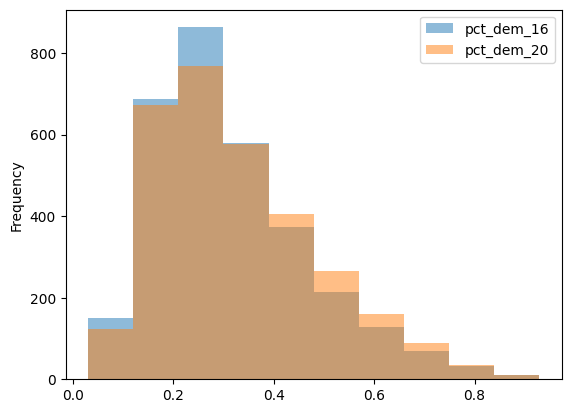

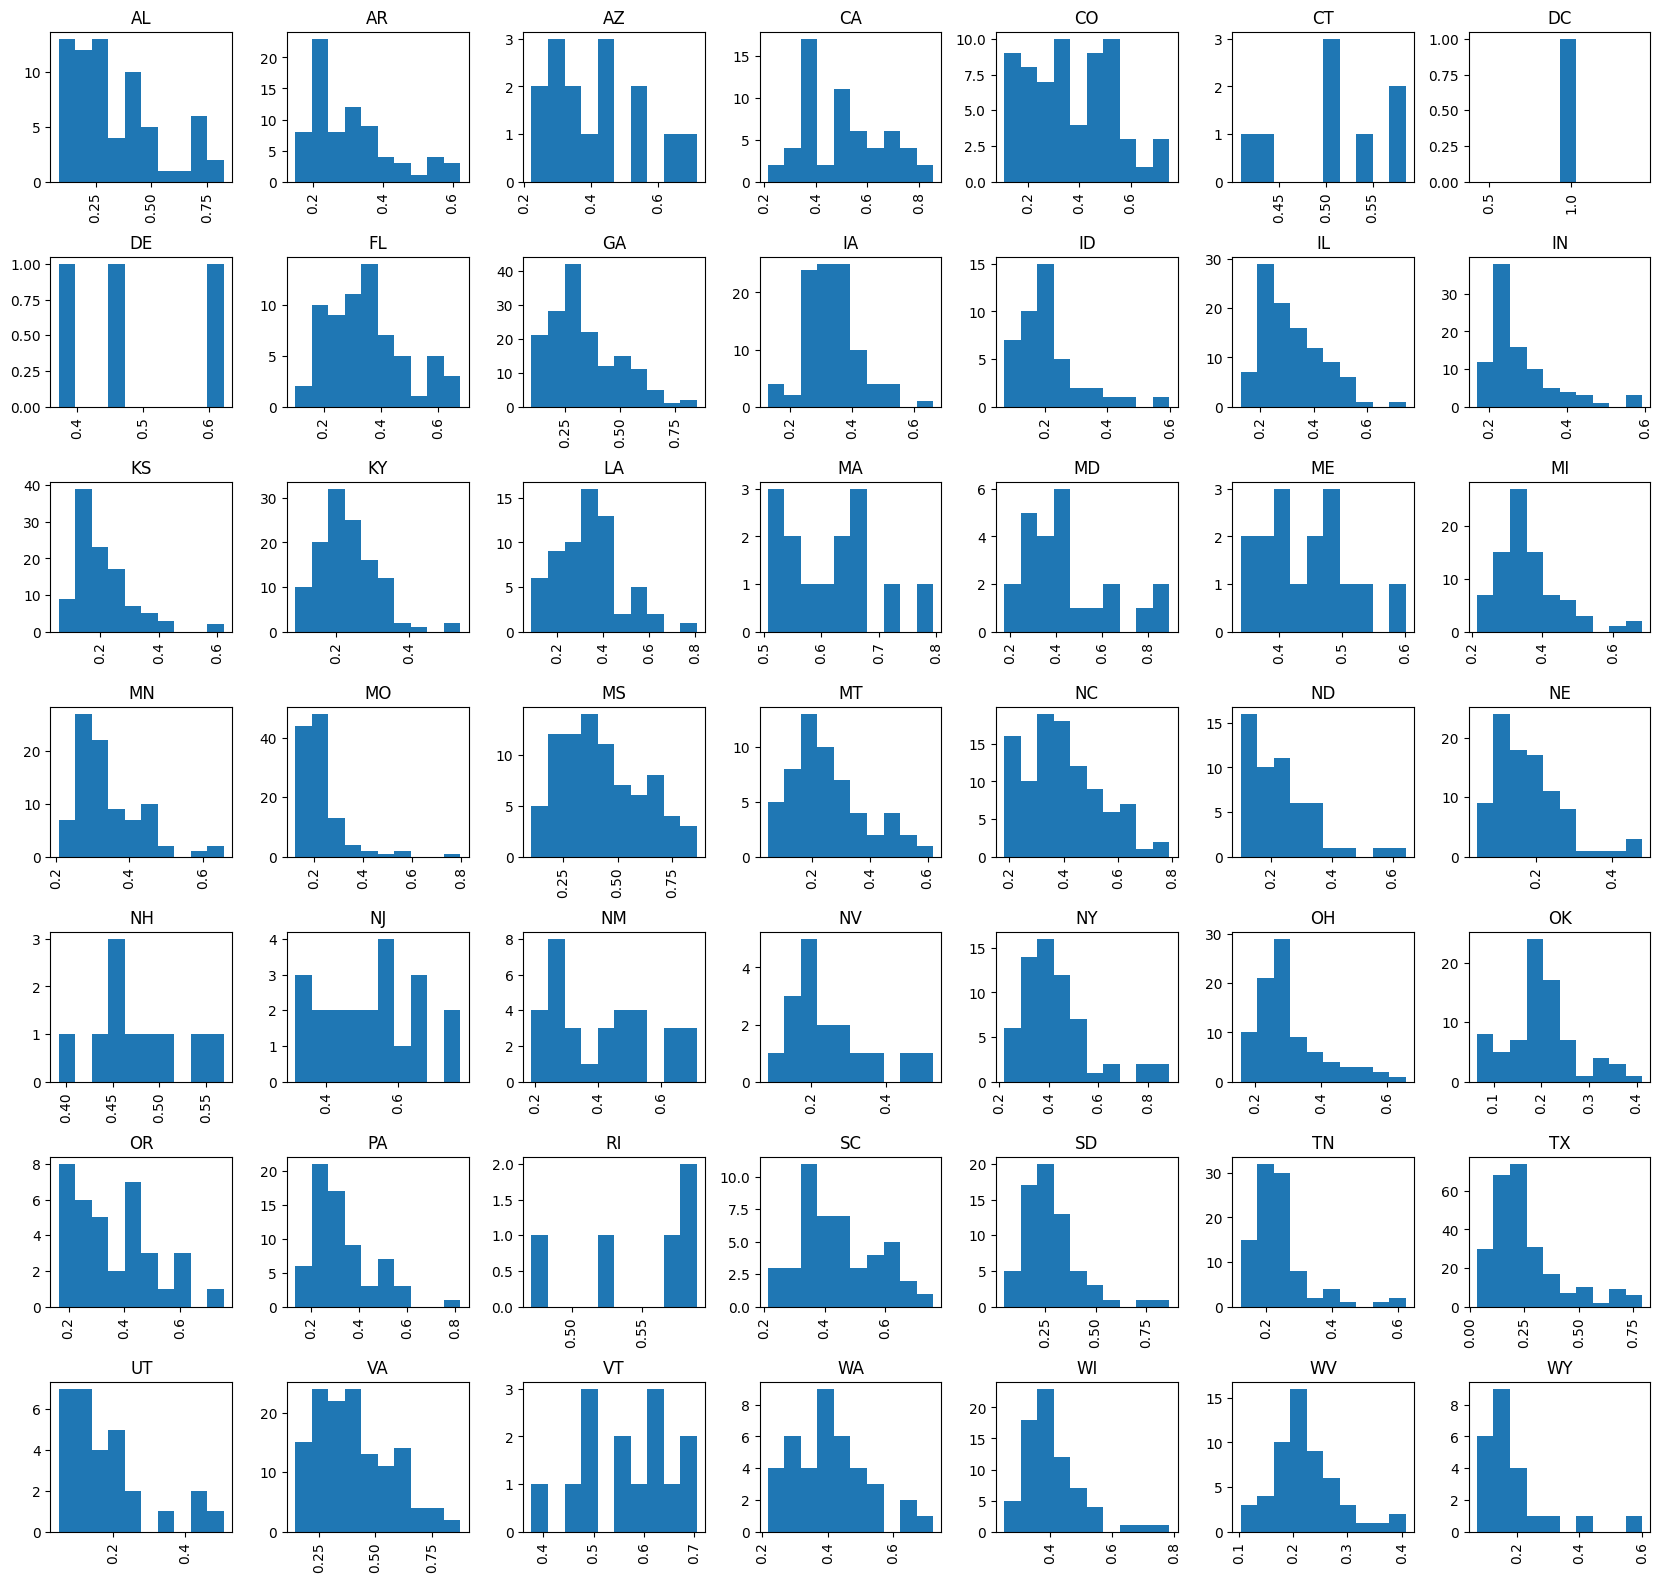

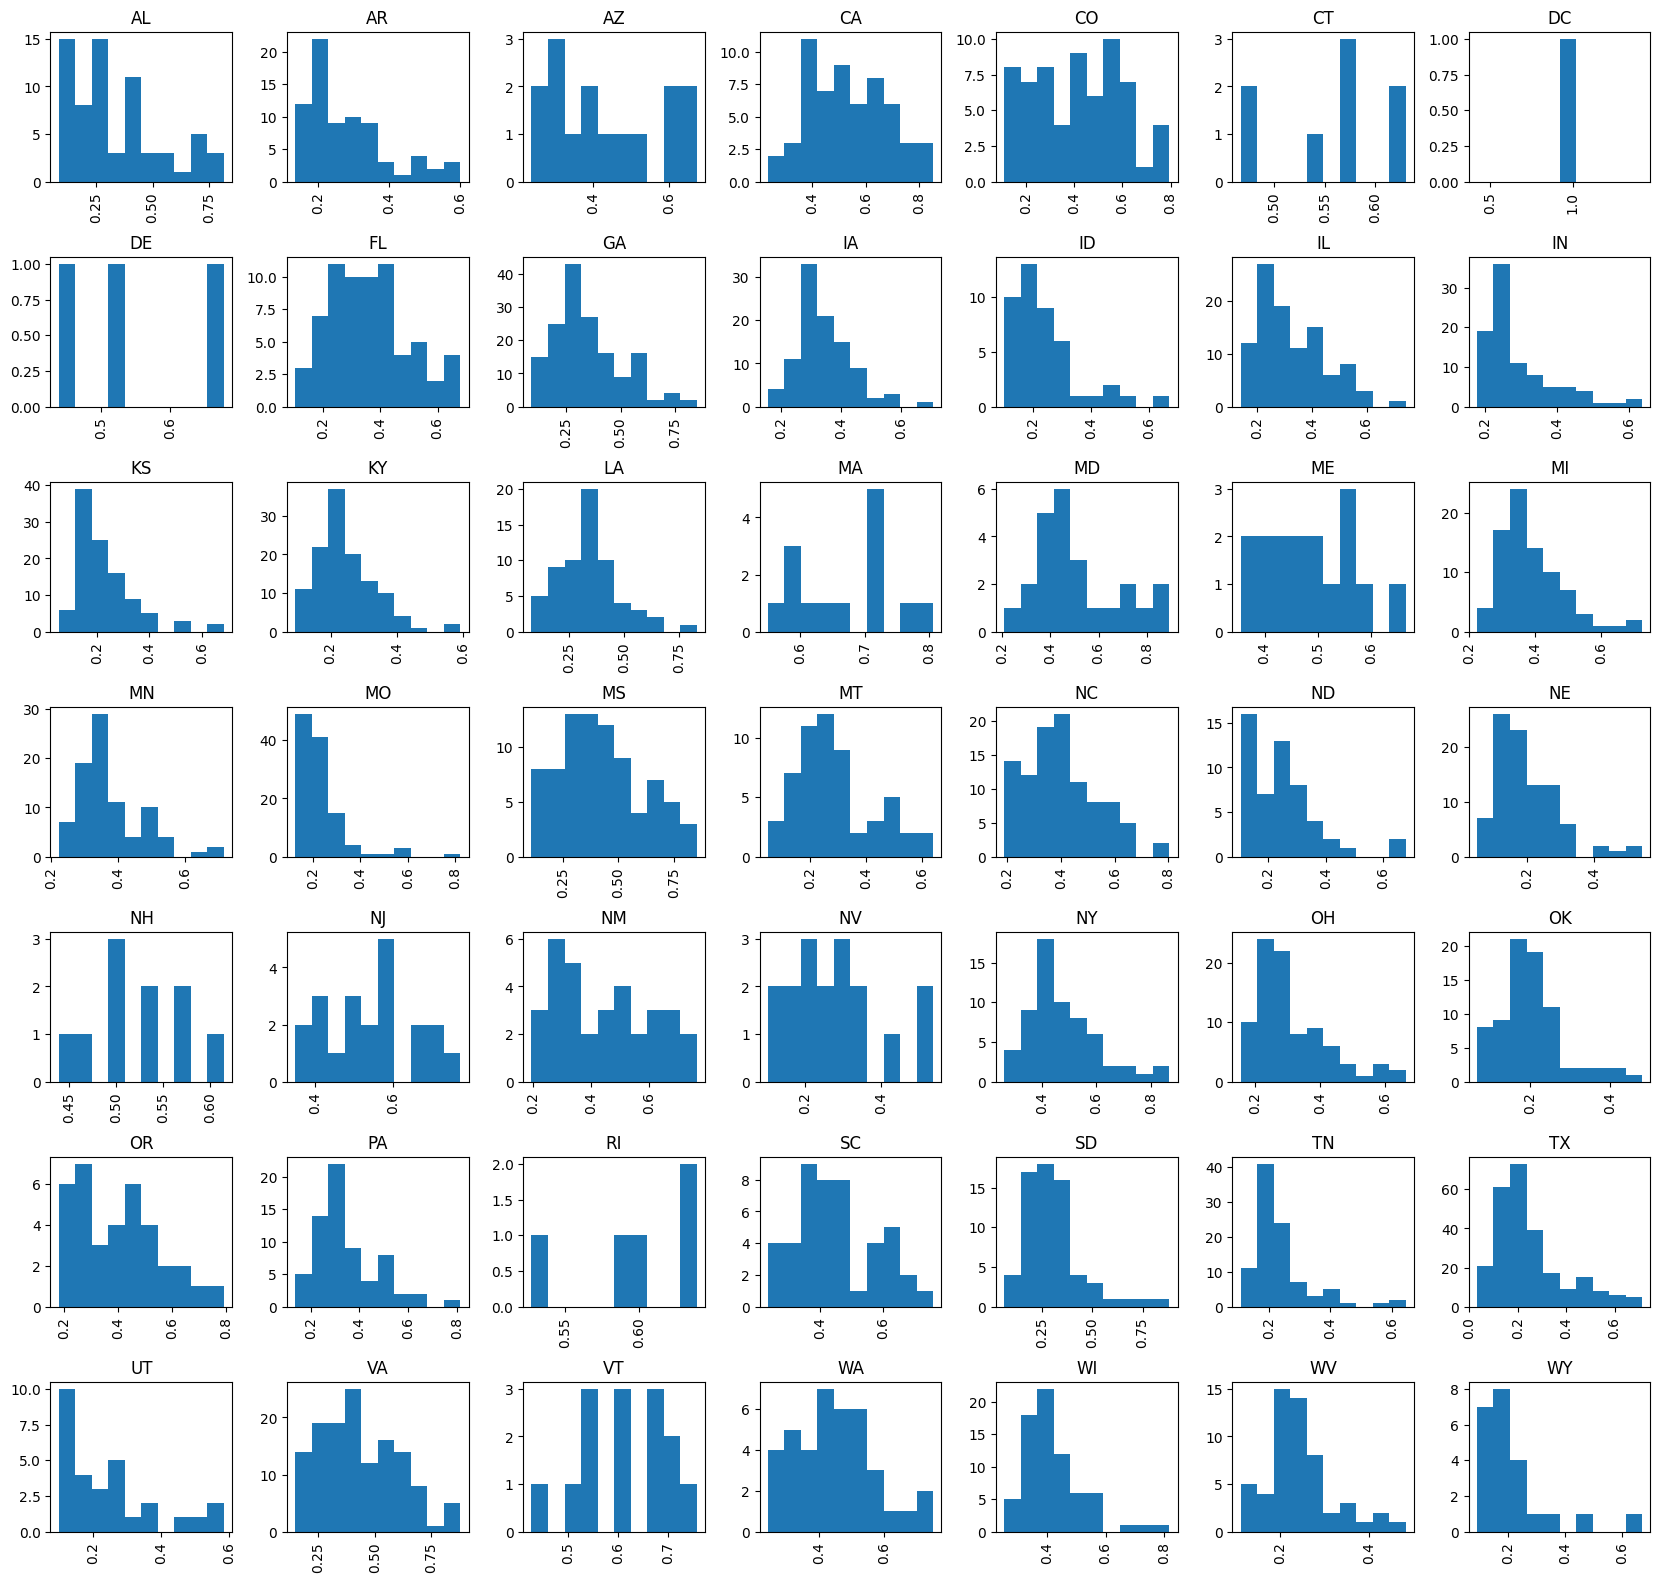

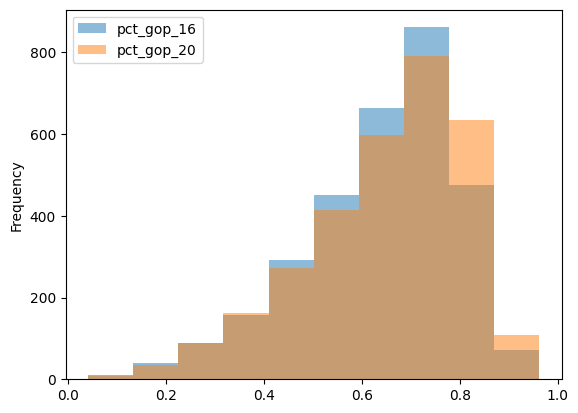

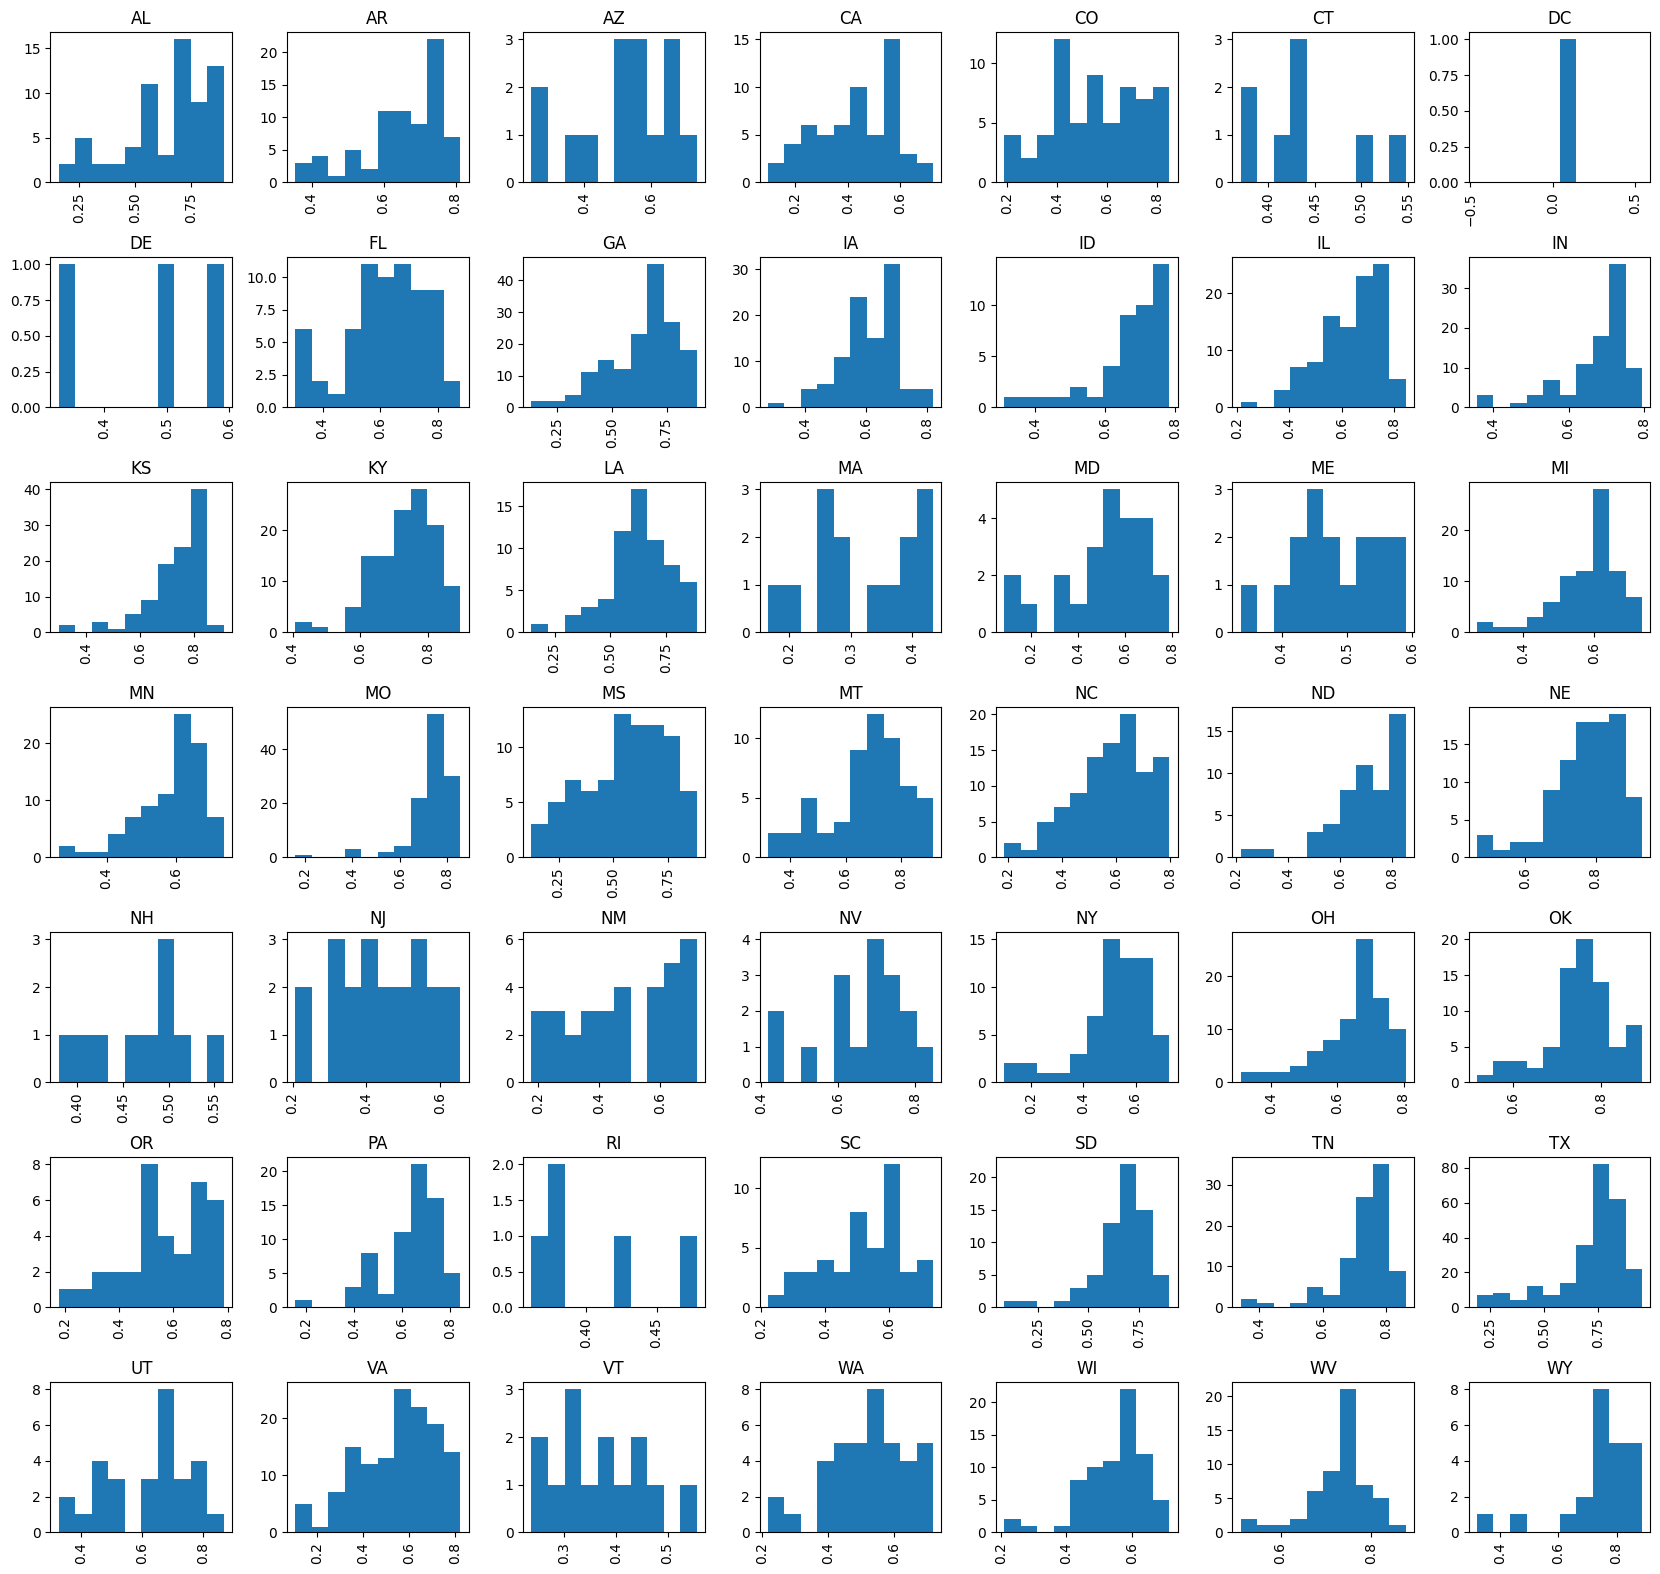

In [ ]:
# Code for exercise 2 goes here

import pandas as pd
import geopandas as gpd
import matplotlib as plt

counties = gpd.read_file('elec_2016_2020.gpkg')

hist16v20d = counties[['pct_dem_16','pct_dem_20']].plot.hist(alpha=0.5)
hist16d = counties.hist('pct_dem_16',by='state_abbr',figsize=(20,20))
hist20d = counties.hist('pct_dem_20',by='state_abbr',figsize=(20,20))
hist16v20r = counties[['pct_gop_16','pct_gop_20']].plot.hist(alpha=0.5)
hist16r = counties.hist('pct_gop_16',by='state_abbr',figsize=(20,20))
hist20r = counties.hist('pct_gop_20',by='state_abbr',figsize=(20,20))

###Exercise 3
Use Folium to create an interactive map with a terrain basemap and at least three markers with pop-ups.

In [ ]:
# Code for exercise 3 goes here

import pandas as pd
import geopandas as gpd
import folium
import xyzservices.providers as xyz

goleta_map = folium.Map(location=[34.440, -119.831], zoom_start=14, tiles=xyz.OpenTopoMap)

folium.Marker(location=[34.40746, -119.87831],popup='Coal Oil Point').add_to(goleta_map)
folium.Marker(location=[34.40582, -119.84458],popup='Campus Point').add_to(goleta_map)
folium.Marker(location=[34.44193, -119.84888],popup='Lake Los Carneros').add_to(goleta_map)

goleta_map

###Exercise 4

Use Folium to create a choropleth map of any polygon data layer other than the one used in the demonstration.

In [ ]:
# Code for exercise 4 goes here

import pandas as pd
import geopandas as gpd
import folium

states = gpd.read_file('election_2020.gpkg',layer='state')

states_map = folium.Map(location=[38,-96],zoom_start=4)

states_layer = folium.Choropleth(
    geo_data=states,
    data=states,
    columns=['STATE_FIPS','P_BIDEN','STATE_NAME'],
    key_on='feature.properties.STATE_FIPS',
    fill_color='Blues',
    fill_opacity=0.7,
    line_opacity=0.2,
    threshold_scale=[-100,-60,-20,0,20,60,100],
    legend_name='Percent Vote Share for Biden by State'
).add_to(states_map)

tooltip = folium.GeoJsonTooltip(['STATE_NAME','P_BIDEN']).add_to(states_layer.geojson)

states_map

###Exercise 5

Use Kepler.gl to make an interactive three-dimensional version of the same data that you used to create a choropleth map for Exercise 4.

In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

In [ ]:
# Code for exercise 5 goes here

import pandas as pd
import geopandas as gpd
from keplergl import KeplerGl
import copy

# states_kepler = KeplerGl(data={"states": states},height=800)

states = gpd.read_file('election_2020.gpkg',layer='state')

states_kepler = KeplerGl(data={"states": states},height=800,config=config)
states_kepler

In [ ]:
config = copy.deepcopy(states_kepler.config)
# will this config stay in memory when my runtime is reset?

##Comprehensive Python Programming Exercise

For this final portion of our last assignment in GEOG 412, you will design and develop a Python application that leverages geospatial data and incorporates geospatial data analysis and visualization techniques, as well as an attractive user interface.

Your application should take the form of a geospatial data analysis and visualization tool, developed within a user interface consisting of IPython widgets.  You may use any geospatial data sources of your interest, and it is recommended that you explore beyond the data sources used in demonstrations and assignments throughout the course.  Feel free to select a topic and datasets of personal or professional interest to you!

Following are specific requirements for your application:

1. Your application must include a user interface developed from IPython widgets.  A tab interface is recommended for organizing multiple visualizations.
2. All user input should be received into the application using IPython widgets (example include text fields, dropdowns, etc.)
3. Your application must include at least two static maps, two static visualizations, and one interactive map (either Folium or Kepler.gl).
4. Your application must include at least one custom class consisting of multiple instance properties, class methods, and a constructor method.
5. Your code should be thoroughly documented using comments.
6. The purpose and functionality of your application should be summarized and introduced within a text box in your Colab notebook.

Your application should incorporate at least several of the following techniques:

* Retrieval of data from a remote API
* Tabular data joins
* Point-in-polygon analysis
* Overlay analysis methods, including buffer analysis
* Kernel density visualization
* Address geocoding
* Distance calculation
* Raster sampling

This portion of your assignment is worth fifteen points.

# **Thanks for trying version 0.1 of the North American Ski Explorer!**
**Please read directions below:**

North American Ski Explorer v0.1 allows users to search for ski resorts and recreation areas within a specified radius of a specified point or place.

This tool receives a place from the user which will be geocoded. Both street addresses and capitalized place names are valid inputs for the geocoder. The tool then receives the user's buffer radius, which is entered in meters. Valid buffer radiuses range from 8,000m to 130,000m (8 km or 130km).

After confirming the validity of your inputs for "Address" and "Radius", click "Go!" to execute your search. If your specified search zone does not return any results, you will be asked to increase your radius or change your location.

If your search returns results, the tool will ask you to select a visualization via dropdown menu. The initially selected value should always be "Interactive map (suggested)", but this visualization will not display; to display a visualization, change the value in the dropdown menu to generate that visualization. If the "Interactive map" is what you're after, simply select something else and reselect it to generate it.

The six visualizations offered show you the same data in different ways:

1.   'Resorts in buffer zone' - will show you your results plotted as red dots on a terrain basemap
2.   'Surrounding region' - will show the region surrounding your results with a street basemap
3. 'Avg temp by resort' - will show a bar chart of the average temperatures at each resort in your search results (in degrees Fahrenheit)
4. 'Elevation by resort' - will show a bar chart of the elevation at each resort in your search results (in US Feet)
5. 'Interactive map (suggested)' - will show a zoomable, panable webmap containing markers for each resort in your search results; click on the markers to view each resort's name and a phone number for local snow conditions
6. 'Table' - will show all data from the above visualizations in one printed table

Execute a new search at any time by changing the values in the original search boxes and clicking "Go!"

Below are some suggested search parameters for getting started:

*   Aspen, Colorado ; 80000
*   Jackson Hole, Wyoming ; 80000
*   Deer Valley, Utah ; 80000
*   Bretton Woods, New Hampshire ; 50000

In [ ]:
# Installation of any necessary modules should be completed here
!pip install geopy pandas geopandas geoplot mapclassify contextily rasterio keplergl
!sudo apt install -y libspatialindex-dev
!pip install rtree

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 14.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 24.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 60.8 MB/s eta 0:00:00
  Using cached jedi-0.19.1-py2.py3-none-any.whl (1.6 MB)
  Created wheel for keplergl: filename=keplergl-0.3.2-py2.py3-none-any.whl size=17922315 sha256=12e1641ed5d5bedcd5f6acf0e8d281883a9b5bb3d0fc7b04ca4eae4d6bce3377
  Stored in directory: /root/.cache/pip/wheels/e5/e9/db/b8b8f2fcb5cb1cd7268d88959fce267bc00697cb8f50dcd0d9
Successfully built keplergl
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libspatialindex-c6 libspatialindex6
The following NEW packages will be installed:
  libspatialindex-c6 libspatialindex-

In [ ]:
!wget = https://leependu.github.io/aggisorg_v10/clean-na_skiresorts.csv
!wget = https://leependu.github.io/aggisorg_v10/masked_na_dtm.tif

--2024-03-20 22:47:18--  http://=/
Resolving = (=)... failed: Name or service not known.
wget: unable to resolve host address ‘=’
--2024-03-20 22:47:18--  https://leependu.github.io/aggisorg_v10/clean-na_skiresorts.csv
Resolving leependu.github.io (leependu.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to leependu.github.io (leependu.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 57970 (57K) [text/csv]
Saving to: ‘clean-na_skiresorts.csv’

clean-na_skiresorts 100%[===================>]  56.61K  --.-KB/s    in 0.001s  

2024-03-20 22:47:18 (44.2 MB/s) - ‘clean-na_skiresorts.csv’ saved [57970/57970]

FINISHED --2024-03-20 22:47:18--
Total wall clock time: 0.09s
Downloaded: 1 files, 57K in 0.001s (44.2 MB/s)
--2024-03-20 22:47:18--  http://=/
Resolving = (=)... failed: Name or service not known.
wget: unable to resolve host address ‘=’
--2024-03-20 22:47:18--  https://leependu.github.io/aggisorg_v10/ma

In [ ]:
################################################################################################################################################################################################
################################################################################################################################################################################################
################################################################################################################################################################################################

# modules

import math
import numpy as np
import requests
import pandas as pd
import geopandas as gpd
import rtree
import rasterio
import rasterio.mask
import mapclassify
import matplotlib.pyplot as plt
import matplotlib.colors as cl
import contextily as cx
import ipywidgets as widgets
import folium
import xyzservices.providers as xyz

from keplergl import KeplerGl
import copy
from google.colab import output
output.enable_custom_widget_manager()

from math import radians, cos, sin, asin, sqrt, degrees, pi, atan2
from geopy.geocoders import Nominatim
from rasterio.plot import show
from IPython.display import display, clear_output
from shapely.geometry import shape, Point

################################################################################################################################################################################################
################################################################################################################################################################################################
################################################################################################################################################################################################

# files

na_skiresorts = pd.read_csv("clean-na_skiresorts.csv")
na_skiresorts = gpd.GeoDataFrame(na_skiresorts,geometry=gpd.points_from_xy(na_skiresorts.longitude, na_skiresorts.latitude),crs=4326) # pd df to gpd gdf
na_skiresorts = na_skiresorts.set_geometry("geometry",crs="EPSG:4326") # set geo
na_skiresorts = na_skiresorts.set_crs(epsg=4326) # set crs
na_skiresorts.crs = "EPSG:4326" # direct crs
na_skiresorts = gpd.GeoDataFrame(na_skiresorts,geometry=na_skiresorts.geometry,crs=4326) # confirm

temperature = rasterio.open('temperature.tif')

elevation = rasterio.open('masked_na_dtm.tif')

################################################################################################################################################################################################
################################################################################################################################################################################################
################################################################################################################################################################################################

#geocoder

geocoder = Nominatim(user_agent='ski_search')

################################################################################################################################################################################################
################################################################################################################################################################################################
################################################################################################################################################################################################

# main widgets

place_box = widgets.Text(value=input("Address: "),placeholder="Address: ",description="Address: ",disabled=False)
buffer_box = widgets.FloatText(value=float(input("Radius in meters (8,000 - 130,000): ")),description="Radius <m>: ",disabled=False)
go_button = widgets.ToggleButton(value=False,description="Go!",disabled=False,button_style="",tooltip="Description",icon="")

################################################################################################################################################################################################
################################################################################################################################################################################################
################################################################################################################################################################################################

# top grid

grid = widgets.GridspecLayout(2,4,height="60px")
grid[0,0] = place_box
grid[0,1] = buffer_box
grid[0,2] = go_button

################################################################################################################################################################################################
################################################################################################################################################################################################
################################################################################################################################################################################################

# explorer

def on_change(event=None):
  if buffer_box.value < 8000:
    clear_output()
    print("Please enter a radius of more than 8 kilometers (8000m).")
    display(grid)
  elif buffer_box.value > 130000:
    clear_output()
    print("Please enter a radius of less than 130 kilometers (130,000m).")
    display(grid)
  else: # proceed with valid buffer radius from input
    clear_output()
    print("Selected place: ",place_box.value)
    print("Defined radius: ",str(int(buffer_box.value))," meters")

    user_place = geocoder.geocode(place_box.value)
    user_pt = {"address":[user_place.address], "geometry":[Point(user_place.longitude, user_place.latitude)]}
    user_gdf = gpd.GeoDataFrame(user_pt, crs=4326) # user's place has been geocoded and saved to epsg:4326 'user_gdf'

    user_gdf_3310 = user_gdf.to_crs(3310) # epsg:4326 'user_gdf' reprojected and saved as epsg:3310 'user_gdf_3310' (meters as linear unit for buffering)
    buffer = user_gdf_3310.buffer(buffer_box.value) # take user's buffer distance / radius
    buffer_df = gpd.GeoDataFrame(buffer,geometry=buffer)
    buffer_df_dissolved = buffer_df.dissolve() # to gdf then dissolve

    buffer_4326 = buffer_df_dissolved.to_crs(crs="4326") # dissolved buffer back to epsg:4326 gdf 'buffer_4326' for sjoin
    buffer_4326 = buffer_4326.set_geometry("geometry",crs="EPSG:4326") # set geo
    buffer_4326 = buffer_4326.set_crs(epsg=4326) # set crs
    buffer_4326.crs = "EPSG:4326" # direct crs
    buffer_4326 = gpd.GeoDataFrame(buffer_4326, geometry=buffer_4326.geometry, crs=4326) # confirm

    buffer_4326_join = gpd.sjoin(left_df=na_skiresorts,right_df=buffer_4326,how="inner",predicate="intersects") # sjoin buffer to na_skiresorts, still epsg:4326
    buffer_4326_join = buffer_4326_join.set_geometry("geometry",crs="EPSG:4326") # set geo
    buffer_4326_join = buffer_4326_join.set_crs(epsg=4326) # set crs
    buffer_4326_join.crs = "EPSG:4326" # direct crs
    buffer_4326_join = gpd.GeoDataFrame(buffer_4326_join, geometry=buffer_4326_join.geometry, crs=4326) # confirm

    buffer_3857_temp = buffer_4326_join.to_crs(crs="3857") # from epsg:4326 project to epsg:3857 for alignment with temperature raster
    buffer_3857_temp = buffer_3857_temp.set_crs(epsg=3857) # set crs
    buffer_3857_temp.crs = "EPSG:3857" # direct crs
    buffer_3857_temp = gpd.GeoDataFrame(buffer_3857_temp, geometry=buffer_3857_temp.geometry, crs=3857) # confirm

    if len(buffer_4326_join.index) == 0: # if user's search returns no results, script will end in error; this 'if' clause allows user to retry without restarting
      print("There are no ski resorts within " + str(int(buffer_box.value)) + " meters of " + str(place_box.value) + ".")
      print("Please enter a different place or a larger radius.")
      display(grid)

    else: # query successful, visualization pending user selection
      display(grid)
      print("There are " + str(len(buffer_4326_join.index)) + " ski resorts within " + str(int(buffer_box.value)) + " meters of " + str(place_box.value) + ".") # count map
      print("Please select a visualization output. Your visualization will generate after you select something new. If you want to view the interactive map, select something else then reselect the interactive map.")
      print("Start a new search at any time.")
      vis_dropdown = widgets.Dropdown(options=['Resorts in buffer zone','Surrounding region','Avg temp by resort','Elevation by resort','Interactive map (suggested)','Table'],value='Interactive map (suggested)',description='Visualization:',disabled=False)
      display(vis_dropdown)

      ########################################################################################################################
      # make data for any of the offered visualizations
      # data originally created for maps plotted sequentially; now all data is saved here so maps can be rendered in any order

      resorts_list = [(x, y) for x, y in zip(buffer_3857_temp['geometry'].x, buffer_3857_temp['geometry'].y)] # sampling temperatures
      buffer_3857_temp['avg_temp'] = [x[0] for x in temperature.sample(resorts_list)]
      buffer_3857_temp['avg_temp_f'] = (buffer_3857_temp['avg_temp'] * (9 / 5)) + 32

      buffer_4326_dtm = buffer_3857_temp.to_crs(crs="4326") # keep 'buffer_3857_temp' gdf for new temperature columns, but project back to epsg:4326 for alignment with elevation raster
      buffer_4326_dtm = buffer_4326_dtm.set_geometry("geometry",crs="EPSG:4326") # set geo
      buffer_4326_dtm = buffer_4326_dtm.set_crs(epsg=4326) # set crs
      buffer_4326_dtm.crs = "EPSG:4326" # direct crs
      buffer_4326_dtm = gpd.GeoDataFrame(buffer_4326_dtm, geometry=buffer_4326_dtm.geometry, crs=4326) # confirm

      resorts_list = [(x, y) for x, y in zip(buffer_4326_dtm['geometry'].x, buffer_4326_dtm['geometry'].y)] # sampling elevation # redundant
      buffer_4326_dtm['elevation'] = [x[0] for x in elevation.sample(resorts_list)]
      buffer_4326_dtm['elevation_ft'] = buffer_4326_dtm['elevation'] * 3.28084

      results = buffer_4326_dtm[['name','address','avg_temp_f','elevation_ft','phone','latitude','longitude']]
      results = gpd.GeoDataFrame(results,geometry=gpd.points_from_xy(results.longitude, results.latitude),crs=4326) # create clean gdf with results
      results = results.set_geometry("geometry",crs="EPSG:4326") # set geo
      results = results.set_crs(epsg=4326) # set crs
      results.crs = "EPSG:4326" # direct crs
      results = gpd.GeoDataFrame(results,geometry=results.geometry,crs=4326) # confirm
      results = results.reset_index() # reset index

      ########################################################################################################################
      # visualization clears and redraws upon user input change

      def new_vis(event=None):
        if vis_dropdown.value == 'Resorts in buffer zone':
          # static map 1
          # plotting results
          #
          clear_output()
          display(grid)
          print("There are " + str(len(buffer_4326_join.index)) + " ski resorts within " + str(int(buffer_box.value)) + " meters of " + str(place_box.value) + ".") # count map
          print("Please select a visualization output.")
          print("Start a new search at any time.")
          display(vis_dropdown)

          fig, ax1 = plt.subplots(figsize=(12,12))
          ax1.set_title(str(len(buffer_4326_join.index)) + " ski resorts within " + str(int(buffer_box.value)) + " meters of " + str(place_box.value),fontsize=16)
          ax1.set_axis_off()
          resort_map = buffer_4326_join.plot(ax=ax1,color="Red",figsize=(12,12),markersize=36.0) # plot
          cx.add_basemap(resort_map,crs=buffer_4326_join.crs,source=cx.providers.OpenTopoMap)

        elif vis_dropdown.value == 'Surrounding region':
          # static map 2
          # road map
          #
          clear_output()
          display(grid)
          print("There are " + str(len(buffer_4326_join.index)) + " ski resorts within " + str(int(buffer_box.value)) + " meters of " + str(place_box.value) + ".") # count map
          print("Please select a visualization output.")
          print("Start a new search at any time.")
          display(vis_dropdown)

          fig, ax2 = plt.subplots(figsize=(12,12))
          ax2.set_title("SURROUNDING REGION",fontsize=16)
          ax2.set_axis_off()
          road_map = buffer_4326_join.plot(ax=ax2,color="Red",figsize=(12,12),markersize=1.0,alpha=0) # plot
          cx.add_basemap(road_map,crs=buffer_4326_join.crs,source=cx.providers.OpenStreetMap.Mapnik)

        elif vis_dropdown.value == 'Avg temp by resort':
          # static vis 1
          # resorts and temperatures
          #
          clear_output()
          display(grid)
          print("There are " + str(len(buffer_4326_join.index)) + " ski resorts within " + str(int(buffer_box.value)) + " meters of " + str(place_box.value) + ".") # count map
          print("Please select a visualization output.")
          print("Start a new search at any time.")
          display(vis_dropdown)

          name = buffer_3857_temp['name']
          avg_temp_f = buffer_3857_temp['avg_temp_f']

          fig = plt.figure(figsize = (16,8)) # avg temp over name vis
          temp_bar = plt.bar(name,avg_temp_f)
          plt.title('Average Temperature by Resort (Fahrenheit)')
          plt.show()

        elif vis_dropdown.value == 'Elevation by resort':
          # static vis 2
          # resorts and elevations
          #
          clear_output()
          display(grid)
          print("There are " + str(len(buffer_4326_join.index)) + " ski resorts within " + str(int(buffer_box.value)) + " meters of " + str(place_box.value) + ".") # count map
          print("Please select a visualization output.")
          print("Start a new search at any time.")
          display(vis_dropdown)

          name = buffer_4326_dtm['name']
          elevation_ft = buffer_4326_dtm['elevation_ft']

          fig = plt.figure(figsize = (16,8)) # elevation over name vis
          plt.bar(name,elevation_ft)
          plt.title('Elevation by Resort (US Feet)')
          plt.show()

        elif vis_dropdown.value == 'Interactive map (suggested)':
          # interactive map
          # folium
          #
          clear_output()
          display(grid)
          print("There are " + str(len(buffer_4326_join.index)) + " ski resorts within " + str(int(buffer_box.value)) + " meters of " + str(place_box.value) + ".") # count map
          print("Please select a visualization output.")
          print("Start a new search at any time.")
          display(vis_dropdown)

          fig = folium.Figure(width=1200, height=800)
          i_map = folium.Map(location=[user_place.latitude, user_place.longitude], zoom_start=9, tiles="OpenStreetMap").add_to(fig)
          fg = folium.FeatureGroup(name="results as feature")

          for index, row in results.iterrows():
            fg.add_child(folium.Marker(location=[row.latitude, row.longitude],
                                       popup=folium.Popup("This is " + str(row['name']) + ". For local snow conditions, call " + str(row.phone),parse_html=True,max_width="100%"),
                                       tooltip=folium.Tooltip(str(row['name']))
                                       ))
          i_map.add_child(fg)
          i_map
          display(fig)

        elif vis_dropdown.value == 'Table':
          clear_output()
          display(grid)
          print("There are " + str(len(buffer_4326_join.index)) + " ski resorts within " + str(int(buffer_box.value)) + " meters of " + str(place_box.value) + ".") # count map
          print("Please select a visualization output.")
          print("Start a new search at any time.")
          display(vis_dropdown)
          print(results)

      vis_dropdown.observe(new_vis,names="value")

# observe
go_button.observe(on_change,names="value")

# start
display(grid)

GridspecLayout(children=(Text(value='Big Bear, California', description='Address: ', layout=Layout(grid_area='…

There are 7 ski resorts within 80000 meters of Big Bear, California.
Please select a visualization output.
Start a new search at any time.


Dropdown(description='Visualization:', index=4, options=('Resorts in buffer zone', 'Surrounding region', 'Avg …